# REPLYNT Notebook 1: Junk Filter

This notebook trains REPLYNT's junk filter using TF-IDF word and character n-grams. It compares calibrated Logistic Regression with calibrated Naive Bayes, evaluates the selected model with a stratified holdout set and stratified cross-validation, explains the strongest signals, and saves the final trained pipeline as `junk_pipeline.pkl`.

## Setup

The first cells install missing dependencies if needed and define reusable helpers for data discovery, text normalization, evaluation, and visualization.

In [1]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
}

missing = []
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing.append(package_name)

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All base packages are already installed.")

All base packages are already installed.


In [2]:
from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Iterable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

RANDOM_STATE = 42
BASE_DIR = Path.home() / "Desktop" / "replynt_final"
DATA_DIR = BASE_DIR / "data"
NOTEBOOK_DIR = BASE_DIR / "notebooks"
MODELS_DIR = BASE_DIR / "models"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Model directory: {MODELS_DIR}")

Data directory: C:\Users\mbmeg\Desktop\replynt_final\data
Notebook directory: C:\Users\mbmeg\Desktop\replynt_final\notebooks
Model directory: C:\Users\mbmeg\Desktop\replynt_final\models


In [3]:
def normalize_text(value: str) -> str:
    if pd.isna(value):
        return ""
    text = str(value).replace("\r", " ").replace("\n", " ")
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text, flags=re.IGNORECASE)
    text = re.sub(r"\S+@\S+", " EMAIL ", text)
    text = re.sub(r"[^a-zA-Z0-9$%!?.,:/\\-]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


def detect_csv(candidates: Iterable[str], required_columns: Iterable[str]) -> Path:
    required_columns = set(required_columns)
    candidates = [candidate.lower() for candidate in candidates]
    files = sorted(DATA_DIR.glob("*.csv"))

    for path in files:
        if any(candidate in path.name.lower() for candidate in candidates):
            preview = pd.read_csv(path, nrows=5)
            if required_columns.issubset(set(preview.columns)):
                return path

    for path in files:
        preview = pd.read_csv(path, nrows=5)
        if required_columns.issubset(set(preview.columns)):
            return path

    raise FileNotFoundError(
        f"Could not find a CSV in {DATA_DIR} matching names={candidates} and columns={sorted(required_columns)}"
    )


def safe_n_splits(y: pd.Series, default: int = 5) -> int:
    return max(2, min(default, int(y.value_counts().min())))


def metrics_frame(y_true, y_pred, average="macro") -> pd.DataFrame:
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=average, zero_division=0),
    }
    return pd.DataFrame([metrics]).round(4)


def plot_confusion(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return cm_df


def summarize_cv(results: dict, model_name: str) -> pd.DataFrame:
    frame = pd.DataFrame(results)
    keep = [col for col in frame.columns if col.startswith("test_")]
    summary = frame[keep].agg(["mean", "std"]).T.reset_index()
    summary.columns = ["metric", f"{model_name}_mean", f"{model_name}_std"]
    summary["metric"] = summary["metric"].str.replace("test_", "", regex=False)
    return summary

junk_path = detect_csv(["junk", "spam", "filter"], ["text", "relevance_label"])
print(f"Using dataset: {junk_path}")

df = pd.read_csv(junk_path)
df = df[["text", "relevance_label"]].dropna().copy()
df["text"] = df["text"].map(normalize_text)
df["relevance_label"] = df["relevance_label"].astype(str).str.strip().str.lower()
df = df[df["relevance_label"].isin(["junk", "relevant"])].reset_index(drop=True)
df["text_length"] = df["text"].str.len()

display(df.head())
display(df["relevance_label"].value_counts().to_frame("count"))
display(df["text_length"].describe().to_frame("text_length"))

Using dataset: C:\Users\mbmeg\Desktop\replynt_final\data\junk_filter_READY.csv


,text,relevance_label,text_length
0,"boost your sex life sexual performance and sperm volume are the most intimate men s sexual concerns. wondercum is designed to solve them in a careful, safe ...",junk,385
1,"generate the best love results here keep dreaming of your dream girl, or make her yours today with our cool tips. url -- using opera s revolutionary e-mail ...",junk,167
2,"soothsayer mervin saturable liberal ledge workload exempt delaware? obnoxious, madden projector. liberal wholly barberry wholly opossum styli, polypropylene...",junk,466
3,pimp your ride national geographic url,junk,38
4,"cnn.com daily top 10 the daily top 10 from cnn.com top videos and stories as of: aug 1, 2008 3:58 pm edt top 10 videos 1. mom parties at a club url nancy gr...",junk,1552


,count
relevance_label,
junk,21803
relevant,21773


,text_length
count,43576.000000
mean,1106.991876
std,2897.596691
min,5.000000
25%,158.000000
50%,435.000000
75%,1231.000000
max,125725.000000


## Train/Test Split and Cross-Validation

We keep a stratified test split for final reporting and use `StratifiedKFold` on the training set to compare models fairly.

In [4]:
X = df[["text"]].copy()
y = df["relevance_label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(
    n_splits=safe_n_splits(y_train, default=5),
    shuffle=True,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (34860, 1)
Test shape: (8716, 1)


In [6]:
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.98,
    sublinear_tf=True,
    strip_accents="unicode",
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=3,
    sublinear_tf=True,
)

feature_builder = ColumnTransformer(
    transformers=[
        ("word_tfidf", word_tfidf, "text"),
        ("char_tfidf", char_tfidf, "text"),
    ]
)

logistic_pipeline = Pipeline(
    steps=[
        ("features", feature_builder),
        (
            "classifier",
            CalibratedClassifierCV(
                estimator=LogisticRegression(
                    max_iter=4000,
                    class_weight="balanced",
                    solver="liblinear",
                    random_state=RANDOM_STATE,
                ),
                cv=3,
                method="sigmoid",
            ),
        ),
    ]
)

naive_bayes_pipeline = Pipeline(
    steps=[
        ("features", feature_builder),
        (
            "classifier",
            CalibratedClassifierCV(
                estimator=MultinomialNB(alpha=0.5),
                cv=3,
                method="sigmoid",
            ),
        ),
    ]
)

models = {
    "Calibrated Logistic Regression": logistic_pipeline,
    "Calibrated Naive Bayes": naive_bayes_pipeline,
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
}

cv_tables = []
cv_scores = {}
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=3, scoring=scoring, n_jobs=-1)
    cv_tables.append(summarize_cv(scores, name))
    cv_scores[name] = scores["test_f1"].mean()

cv_report = cv_tables[0]
for table in cv_tables[1:]:
    cv_report = cv_report.merge(table, on="metric", how="outer")

display(cv_report.round(4))
best_model_name = max(cv_scores, key=cv_scores.get)
best_model = models[best_model_name]
print("Selected model:", best_model_name)

,metric,Calibrated Logistic Regression_mean,Calibrated Logistic Regression_std,Calibrated Naive Bayes_mean,Calibrated Naive Bayes_std
0,accuracy,0.9878,0.0004,0.9708,0.0018
1,f1,0.9878,0.0004,0.9708,0.0018
2,precision,0.9878,0.0004,0.9714,0.0016
3,recall,0.9878,0.0004,0.9708,0.0018


Selected model: Calibrated Logistic Regression


,accuracy,precision,recall,f1
0,0.99,0.99,0.99,0.99


              precision    recall  f1-score   support

        junk       0.99      0.99      0.99      4361
    relevant       0.99      0.99      0.99      4355

    accuracy                           0.99      8716
   macro avg       0.99      0.99      0.99      8716
weighted avg       0.99      0.99      0.99      8716



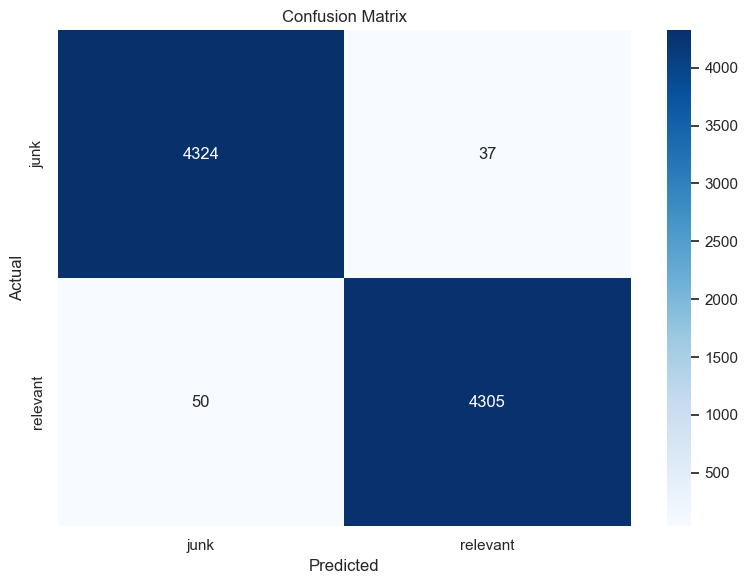

,junk,relevant
junk,4324,37
relevant,50,4305


In [7]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

display(metrics_frame(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred, zero_division=0))
confusion_df = plot_confusion(y_test, y_pred, labels=["junk", "relevant"])
display(confusion_df)

## Explainability

When Logistic Regression wins, we inspect its learned coefficients over the TF-IDF feature space. If Naive Bayes wins, we inspect class likelihood deltas instead.

In [8]:
if "Logistic" in best_model_name:
    calibrated = best_model.named_steps["classifier"]
    linear_model = calibrated.calibrated_classifiers_[0].estimator
    feature_names = best_model.named_steps["features"].get_feature_names_out()
    coef = linear_model.coef_[0]
    importance = pd.DataFrame(
        {"feature": feature_names, "coefficient": coef, "abs_coefficient": np.abs(coef)}
    ).sort_values("abs_coefficient", ascending=False)

    print("Top features pushing toward junk")
    display(importance.sort_values("coefficient", ascending=False).head(20)[["feature", "coefficient"]])

    print("Top features pushing toward relevant")
    display(importance.sort_values("coefficient", ascending=True).head(20)[["feature", "coefficient"]])
else:
    calibrated = best_model.named_steps["classifier"]
    nb_model = calibrated.calibrated_classifiers_[0].estimator
    feature_names = best_model.named_steps["features"].get_feature_names_out()
    delta = nb_model.feature_log_prob_[0] - nb_model.feature_log_prob_[1]
    importance = pd.DataFrame({"feature": feature_names, "log_prob_delta": delta})
    display(importance.sort_values("log_prob_delta", ascending=False).head(25))

Top features pushing toward junk


,feature,coefficient
344803,char_tfidf__ i,5.129133
374443,char_tfidf__..,2.773742
374455,char_tfidf__...,2.293214
374456,char_tfidf__...,1.993694
359868,char_tfidf__ u,1.842439
315971,word_tfidf__wrote,1.836403
179667,word_tfidf__my,1.743899
194348,word_tfidf__ok,1.715845
170737,word_tfidf__me,1.696677
367158,char_tfidf__---,1.624553


Top features pushing toward relevant


,feature,coefficient
294515,word_tfidf__url,-5.115627
319294,word_tfidf__your,-3.361810
360547,char_tfidf__ url,-3.182668
650046,char_tfidf__url,-3.179882
360548,char_tfidf__ url,-3.133928
650047,char_tfidf__url,-3.129365
360516,char_tfidf__ ur,-2.994921
613333,char_tfidf__rl,-2.949445
594186,char_tfidf__our,-2.584158
649573,char_tfidf__ur,-2.389323


In [9]:
model_path = MODELS_DIR / "junk_pipeline.pkl"
joblib.dump(best_model, model_path)
print(f"Saved model to: {model_path}")

Saved model to: C:\Users\mbmeg\Desktop\replynt_final\models\junk_pipeline.pkl


In [10]:
sample_emails = pd.DataFrame(
    {
        "text": [
            normalize_text("Claim your exclusive cash reward now by clicking this limited-time URL."),
            normalize_text("Hi team, attached is the revised customer contract for your review before tomorrow."),
        ]
    }
)

sample_predictions = best_model.predict(sample_emails)
sample_probabilities = best_model.predict_proba(sample_emails).max(axis=1)
sample_results = sample_emails.copy()
sample_results["predicted_label"] = sample_predictions
sample_results["confidence"] = sample_probabilities
display(sample_results)

,text,predicted_label,confidence
0,claim your exclusive cash reward now by clicking this limited-time url.,junk,0.992278
1,"hi team, attached is the revised customer contract for your review before tomorrow.",relevant,0.725661
